In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import pandas as pd

In [15]:
# ==========================================================
# FILE LISTS
# ==========================================================

original_files = [
    "AML Validation.csv",
    "BreastCancerValidation.csv",
    "Lung Cancer Validation.csv"
]

partial_files = [
    "AML Validation partial.csv",
    "Breast Cancer Validation partial.csv",
    "Lung Cancer Validation Partial.csv"
]

random_files = [
    "AML_Random_validation.csv",
    "Breast_Random_validation.csv",
    "Lung_Random_validation.csv"
]


def merge_csvs(file_list, output_file):
    dfs = []

    for file in file_list:
        df = pd.read_csv(file)

        df["source_file"] = file

        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)

    merged.to_csv(output_file, index=False)

    print(f"Saved: {output_file} ({len(merged):,} rows)")

    return merged


# ==========================================================
# 1. MERGE ALL 9 FILES
# ==========================================================

all_files = (
    original_files +
    partial_files +
    random_files
)

merge_csvs(
    all_files,
    "All_Validation_Merged.csv"
)

# ==========================================================
# 2. MERGE ORIGINAL FILES
# ==========================================================

merge_csvs(
    original_files,
    "Original_Validation_Merged.csv"
)

# ==========================================================
# 3. MERGE PARTIAL FILES
# ==========================================================

merge_csvs(
    partial_files,
    "Partial_Validation_Merged.csv"
)

# ==========================================================
# 4. MERGE RANDOM FILES
# ==========================================================

merge_csvs(
    random_files,
    "Random_Validation_Merged.csv"
)

print("\nDone.")

Saved: All_Validation_Merged.csv (723 rows)
Saved: Original_Validation_Merged.csv (241 rows)
Saved: Partial_Validation_Merged.csv (241 rows)
Saved: Random_Validation_Merged.csv (241 rows)

Done.


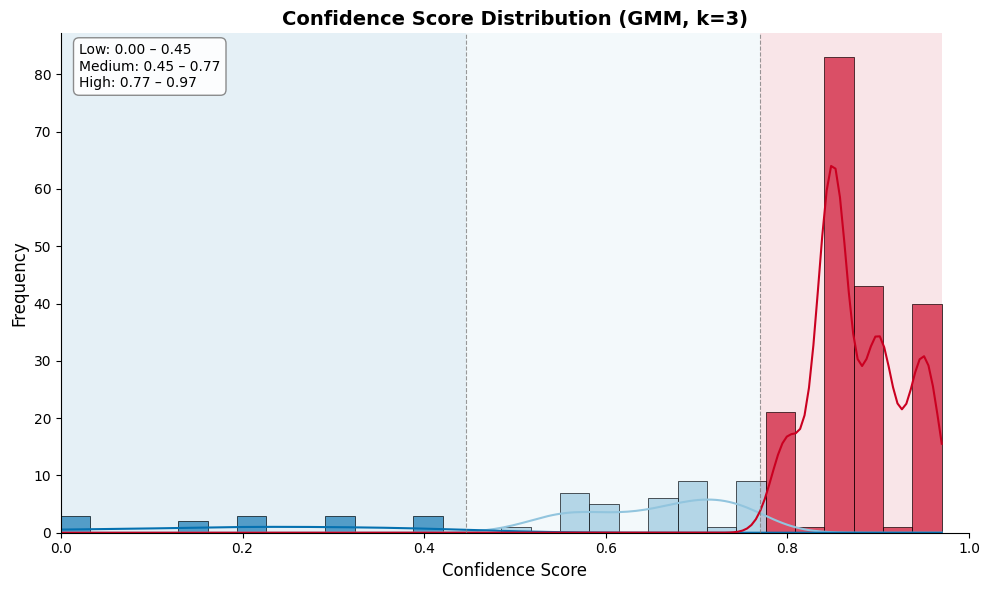

Low: n=14, mean=0.215, range=0.00-0.45
Medium: n=38, mean=0.659, range=0.45-0.77
High: n=189, mean=0.877, range=0.77-0.97


In [19]:
df = pd.read_csv("Original_Validation_Merged.csv")
df['Final_Confidence'] = pd.to_numeric(df['Final_Confidence'], errors='coerce')
df = df.dropna(subset=['Final_Confidence']).reset_index(drop=True)
X = df['Final_Confidence'].values.reshape(-1, 1)

n_components = 3
palette_colors = ["#0571b0", "#92c5de", "#ca0020"]

gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(X)
means = gmm.means_.flatten()
order = np.argsort(means)
sorted_means = means[order]

thresholds = [(sorted_means[i] + sorted_means[i+1]) / 2.0 for i in range(len(sorted_means)-1)]
thresholds = np.array(thresholds)

global_min = float(df['Final_Confidence'].min())
global_max = float(df['Final_Confidence'].max())
bin_edges = np.concatenate(([global_min], thresholds, [global_max]))

binned = np.digitize(df['Final_Confidence'].values, bins=thresholds)
df['GMM_Bin'] = binned

names = ['Low', 'Medium', 'High'][:n_components]
ordered_labels = [names[i] for i in range(n_components)]
palette = {ordered_labels[i]: palette_colors[i] for i in range(n_components)}
df['Confidence_Label'] = df['GMM_Bin'].map({i: ordered_labels[i] for i in range(n_components)})

range_lines = []
for i in range(n_components):
    lo = bin_edges[i]
    hi = bin_edges[i+1]
    range_lines.append(f"{ordered_labels[i]}: {lo:.2f} – {hi:.2f}")

textbox_text = "\n".join(range_lines)
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='Final_Confidence',
    hue='Confidence_Label',
    bins=30,
    kde=True,
    palette=palette,
    alpha=0.65,
    edgecolor='black',
    linewidth=0.5,
    legend=False
)

ax.set_xlim(0, 1)
ax.set_xlabel('Confidence Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Confidence Score Distribution (GMM, k={n_components})', fontsize=14, fontweight='bold')

ymax = ax.get_ylim()[1]
alpha_band = 0.10
for i in range(n_components):
    lo = bin_edges[i]
    hi = bin_edges[i+1]
    color = palette[ordered_labels[i]]
    ax.axvspan(lo, hi, color=color, alpha=alpha_band, linewidth=0)

for t in thresholds:
    ax.axvline(t, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)

bbox_props = dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.9)
ax.text(
    0.02, 0.98, textbox_text,    
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=bbox_props
)

sns.despine(trim=False)
plt.tight_layout()
plt.show()

for i in range(n_components):
    members = df[df['GMM_Bin'] == i]['Final_Confidence']
    print(f"{ordered_labels[i]}: n={len(members)}, mean={members.mean():.3f}, range={bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}")